# Introduction to Machine Learning with PyTorch
## Project: Finding Donors for *CharityML*

Steffany McWaters
Python version 3.13.0

----
## Exploring the Data


In [2]:
# Import libraries necessary for this project
import numpy as np
import pandas as pd
from time import time
from IPython.display import display # Allows the use of display() for DataFrames
from sklearn.svm import SVC

# Import supplementary visualization code visuals.py
import visuals as vs

# Pretty display for notebooks
%matplotlib inline

# Load the Census dataset
data = pd.read_csv("census.csv")

# Success - Display the first record
display(data.head(n=1))

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K


### Implementation: Data Exploration


In [3]:
# List the data types to better understand how the data is recorded.
data.dtypes

age                  int64
workclass              str
education_level        str
education-num      float64
marital-status         str
occupation             str
relationship           str
race                   str
sex                    str
capital-gain       float64
capital-loss       float64
hours-per-week     float64
native-country         str
income                 str
dtype: object

In [4]:
# Record the total number of records in variable n_records
n_records = data.shape[0]

# Record the number of records where individual's income is more than $50,000 in variable n_greater_50k
n_greater_50k = (data['income'] == '>50K').sum()

# Record the number of records where an individual's income is at most $50,000 in variable n_at_most_50k
n_at_most_50k = (data['income'] == '<=50K').sum()
# Record the percent of individuals who make at most $50,000 in variable lesser_percent
lesser_percent = n_at_most_50k / n_records

# Record the percent of individuals whose income is more than $50,000 in variable greater_percent
greater_percent = n_greater_50k / n_records

# Print the results
print("Total number of records: {}".format(n_records))
print("Individuals making more than $50,000: {}".format(n_greater_50k))
print("Individuals making at most $50,000: {}".format(n_at_most_50k))
print("Percentage of individuals making more than $50,000: {}%".format(greater_percent))

Total number of records: 45222
Individuals making more than $50,000: 11208
Individuals making at most $50,000: 34014
Percentage of individuals making more than $50,000: 0.2478439697492371%


**Featureset Exploration**

* **age**: continuous. 
* **workclass**: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked. 
* **education**: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool. 
* **education-num**: continuous. 
* **marital-status**: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse. 
* **occupation**: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces. 
* **relationship**: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried. 
* **race**: Black, White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other. 
* **sex**: Female, Male. 
* **capital-gain**: continuous. 
* **capital-loss**: continuous. 
* **hours-per-week**: continuous. 
* **native-country**: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

### Transforming Skewed Continuous Features
Plot a histogram of the skewed features 'capital-gain' and 'capital-loss'

C:\Users\steff\PycharmProjects\JupyterProject2\visuals.py:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


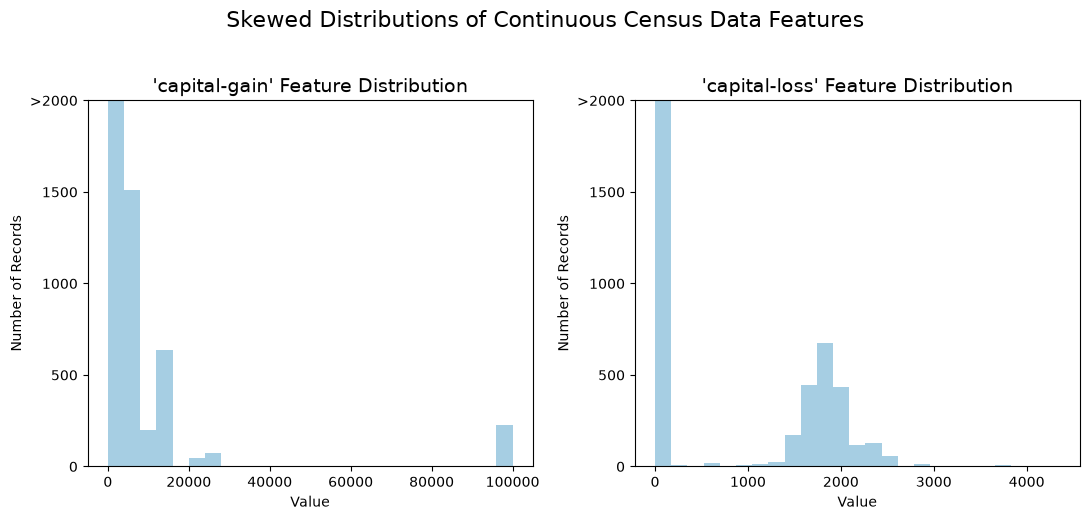

In [23]:
# Split the data into features and target label
income_raw = data['income']
features_raw = data.drop('income', axis = 1)

# Visualize skewed continuous features of original data
vs.distribution(data)

Use a logarithmic transformation on the highly-skewed feature distribution 'capital-gain' and 'capital-loss', translating 0 values by a small amount

C:\Users\steff\PycharmProjects\JupyterProject2\visuals.py:50: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


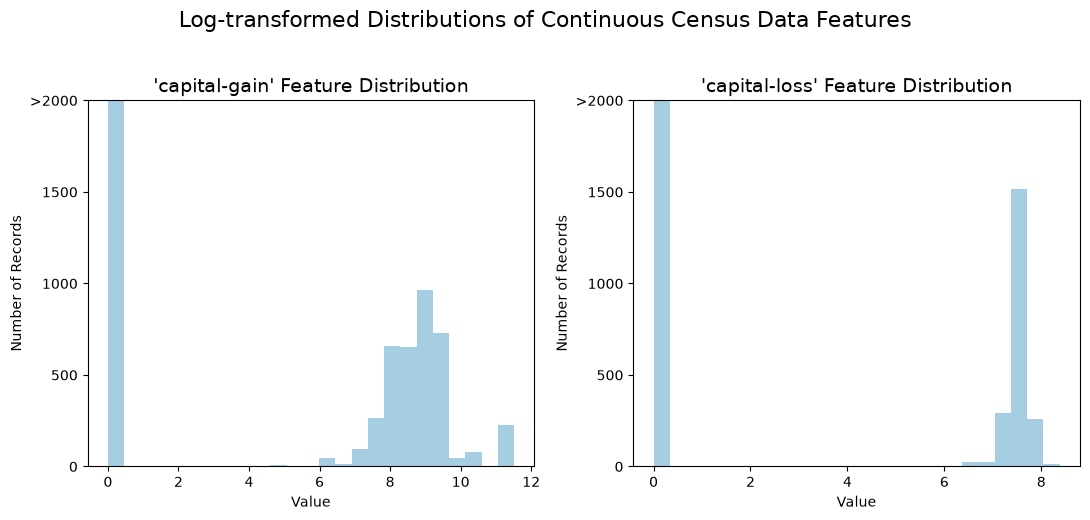

In [24]:
# Log-transform the skewed features
skewed = ['capital-gain', 'capital-loss']
features_log_transformed = pd.DataFrame(data = features_raw)
features_log_transformed[skewed] = features_raw[skewed].apply(lambda x: np.log(x + 1))

# Visualize the new log distributions
vs.distribution(features_log_transformed, transformed = True)

### Normalizing Numerical Features
Normalize numerical features to ensure they are treated equally when applying supervised learners.

In [25]:
# Import the appropriate packages
from sklearn.preprocessing import MinMaxScaler

# Initialize a scaler, then apply it to the features
scaler = MinMaxScaler() # default=(0, 1)
numerical = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

features_log_minmax_transform = pd.DataFrame(data = features_log_transformed)
features_log_minmax_transform[numerical] = scaler.fit_transform(features_log_transformed[numerical])

# Show an example of a record with scaling applied
display(features_log_minmax_transform.head(n = 5))

,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,0.301370,State-gov,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.667492,0.0,0.397959,United-States
1,0.452055,Self-emp-not-inc,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.000000,0.0,0.122449,United-States
2,0.287671,Private,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.000000,0.0,0.397959,United-States
3,0.493151,Private,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.000000,0.0,0.397959,United-States
4,0.150685,Private,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.000000,0.0,0.397959,Cuba


### Implementation: Data Preprocessing

Recode non-numeric features as follows:
 - Use [`pandas.get_dummies()`](http://pandas.pydata.org/pandas-docs/stable/generated/pandas.get_dummies.html?highlight=get_dummies#pandas.get_dummies) to perform one-hot encoding on the `features_log_minmax_transform` data.
 - Convert the target label `income_raw` to numerical entries.
   - Set records with "<=50K" to 0 and records with ">50K" to 1.

In [26]:
# One-hot encode the 'features_log_minmax_transform' data using pandas.get_dummies()
features_final = pd.get_dummies(features_log_minmax_transform)

# Encode the 'income_raw' data to numerical values
income = income_raw.apply(lambda x: 0 if x == "<=50K" else 1)

# Print the number of features after one-hot encoding
encoded = list(features_final.columns)
print("{} total features after one-hot encoding.".format(len(encoded)))

# Print the encoded feature names
print(encoded)

103 total features after one-hot encoding.
['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass_ Federal-gov', 'workclass_ Local-gov', 'workclass_ Private', 'workclass_ Self-emp-inc', 'workclass_ Self-emp-not-inc', 'workclass_ State-gov', 'workclass_ Without-pay', 'education_level_ 10th', 'education_level_ 11th', 'education_level_ 12th', 'education_level_ 1st-4th', 'education_level_ 5th-6th', 'education_level_ 7th-8th', 'education_level_ 9th', 'education_level_ Assoc-acdm', 'education_level_ Assoc-voc', 'education_level_ Bachelors', 'education_level_ Doctorate', 'education_level_ HS-grad', 'education_level_ Masters', 'education_level_ Preschool', 'education_level_ Prof-school', 'education_level_ Some-college', 'marital-status_ Divorced', 'marital-status_ Married-AF-spouse', 'marital-status_ Married-civ-spouse', 'marital-status_ Married-spouse-absent', 'marital-status_ Never-married', 'marital-status_ Separated', 'marital-status_ Widowed', 'occupation_ A

### Shuffle and Split Data
Split the data into training and testing sets (20% of data should be reserved for testing.)

In [27]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split the 'features' and 'income' data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features_final, 
                                                    income, 
                                                    test_size = 0.2, 
                                                    random_state = 0)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

Training set has 36177 samples.
Testing set has 9045 samples.


----
## Evaluating Model Performance
Evaluate the performance of 4 models: Naive Predictor, Logistic Regression, Random Forest Classifier, and Gradient Boosting Classifier using the metrics accuracy and F-score (beta = 0.5).

### Question 1 - Naive Predictor Performace

In [28]:
TP = np.sum(income) # Counting the ones as this is the naive case. Note that 'income' is the 'income_raw' data encoded to numerical values done in the data preprocessing step.
FP = income.count() - TP # Specific to the naive case

TN = 0 # No predicted negatives in the naive case
FN = 0 # No predicted negatives in the naive case

# Calculate accuracy, precision and recall
accuracy = (TP + TN) / len(income)
recall = TP / (TP + FN)
precision = TP / (TP + FP)

# Calculate F-score using the formula above for beta = 0.5 and correct values for precision and recall.
beta = 0.5
fscore = (1 + beta**2) * (precision * recall) /((beta**2 * precision) + recall)

# Print the results
print("Naive Predictor: [Accuracy score: {:.4f}, F-score: {:.4f}]".format(accuracy, fscore))

Naive Predictor: [Accuracy score: 0.2478, F-score: 0.2917]


### Question 2 - Model Application
List three of the supervised learning models above that are appropriate for this problem that you will test on the census data. For each model chosen

- Describe one real-world application in industry where the model can be applied. 
- What are the strengths of the model; when does it perform well?
- What are the weaknesses of the model; when does it perform poorly?
- What makes this model a good candidate for the problem, given what you know about the data?

**Answer:**

Model 1: Logistic Regression

One real-world application of the Logistic Regression Model is credit card fraud detection in the banking industry. Given historical data on credit card transactions and whether each was fraudulent, a Logistic Regression model can estimate the probability of fraud with new transactions. If the predicted probability exceeds a threshold chosen to minimize false negatives, the bank can automatically decline or flag the transaction, resulting in significant savings by reducing the number of costly fraudulent transactions.

Logistic Regression performs well on binary classification problems, especially when there exists sufficient training data and the relationship between the feature variables and the log-odds of the target variable is approximately linear. Furthermore, when data are preprocessed appropriately, such as with scaling continuous variables, one-hot encoding categorical variables, and logarithmically transforming highly skewed variables, this model can be further improved, leading to easily interpretable results (Logistic Regression, 2026).

Logistic Regression performs less reliably when the relationship between the feature variables and the target variable is highly non-linear. It is also not appropriate to use when there exists extreme multicollinearity among the predictors or when the observations are not independent of one another. Moreover, this model would perform poorly in situations that are not binary classification problems or when the number of available training observations is inadequate, or when the training set contains outliers that influence the results (Radečić, 2026).

The Logistic Regression model is a good candidate for predicting whether an individual makes more than \\$50,000 per year for several reasons. The target variable has only two possible outcomes: the individual earns up to \\$50,000 per year or earns over $50,000 per year, making this a binary classification task. The sample size is large, with over 35,000 data points in the training set, allowing the model’s parameters to be estimated more reliably and reducing the likelihood of overfitting due to insufficient training data. An events-per-variable of approximately 108 (11,208 over \\$50K observations divided by 103 predictors after one-hot encoding) further confirms the adequacy of the sample size, according to Dario Radečić in his 2026 article, Logistic Regression Assumptions: What You Need to Check Before Modeling. Additionally, one-hot encoding converts categorical variables into numerical indicators, allowing them to be used as inputs in this model. Furthermore, although the features were not formally tested for a linear relationship with the log odds of the income variable, preprocessing was performed to make the data more suitable for this model. The highly skewed capital-gain and capital-loss variables were transformed logarithmically to reduce skewness, and the continuous features age, education-num, capital-gain, capital-loss, and hours-per-week were normalized to ensure all features were on comparable scales during model training.

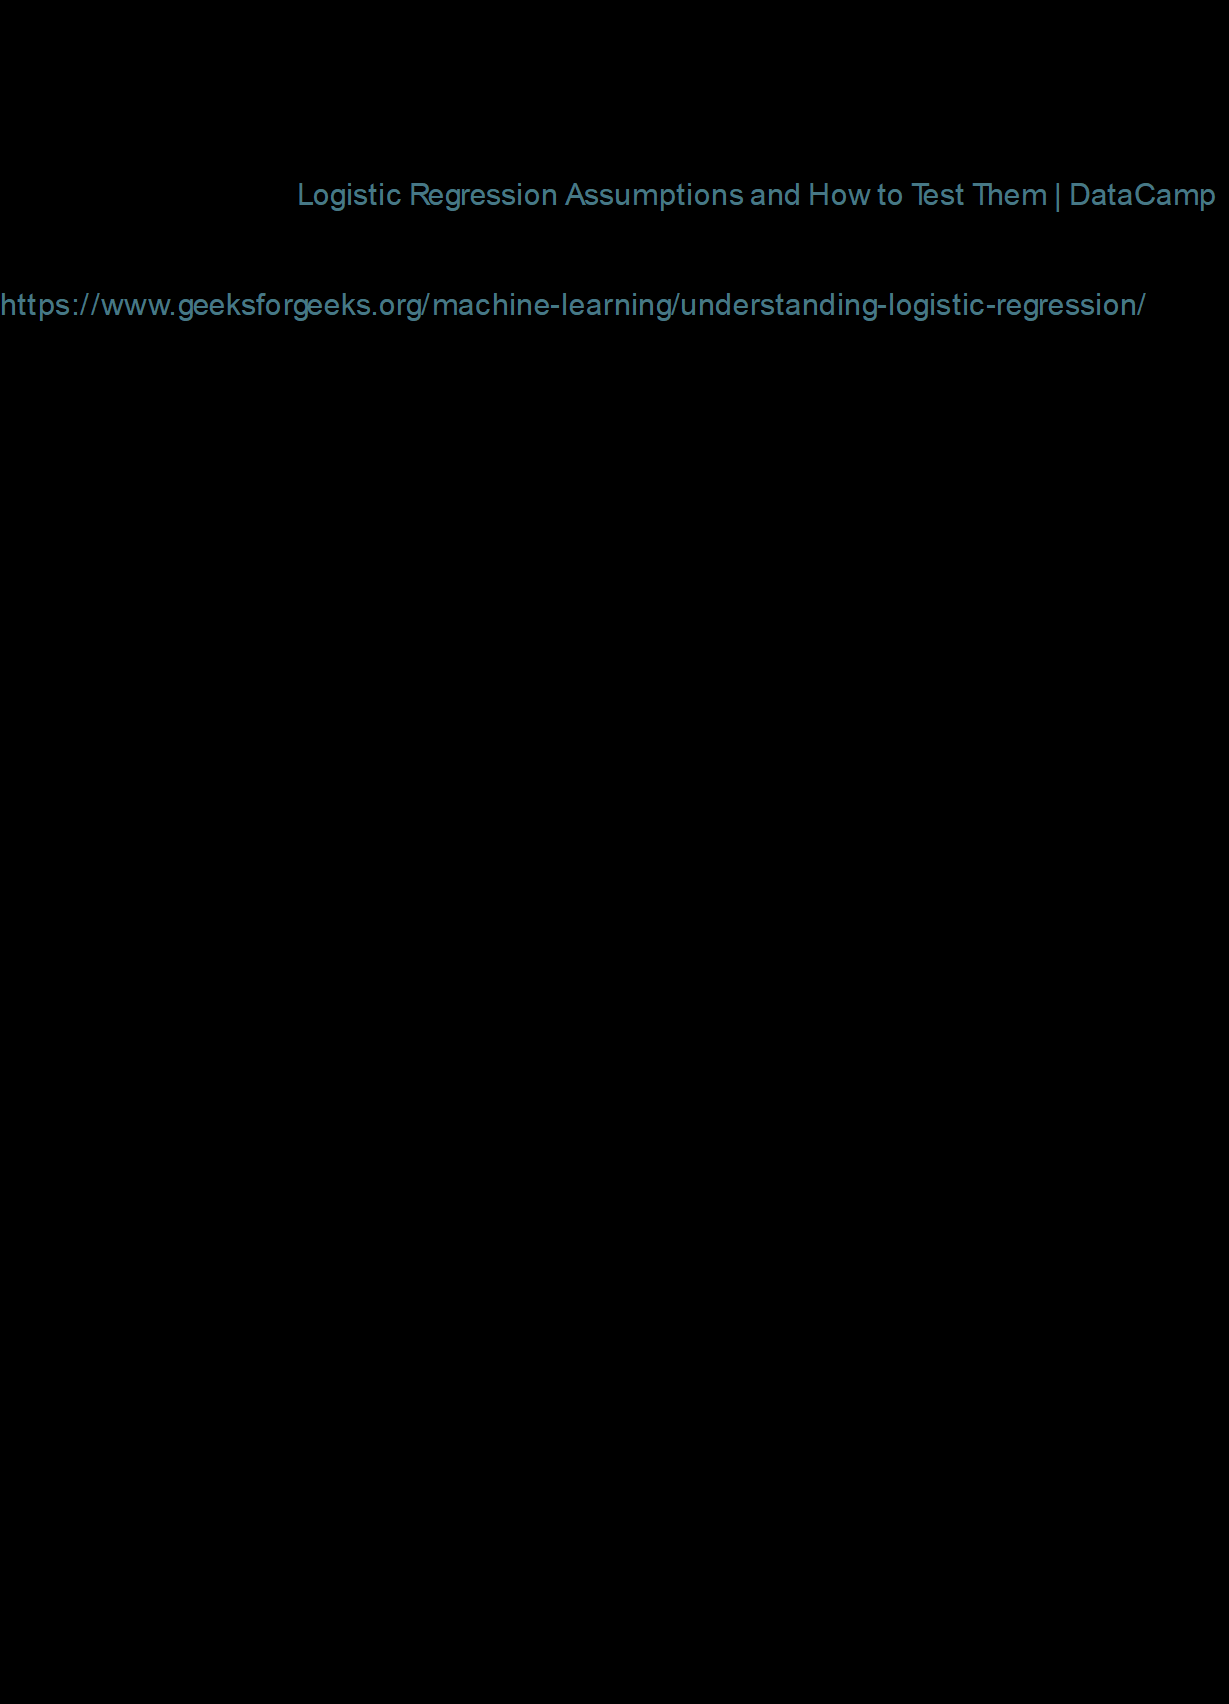
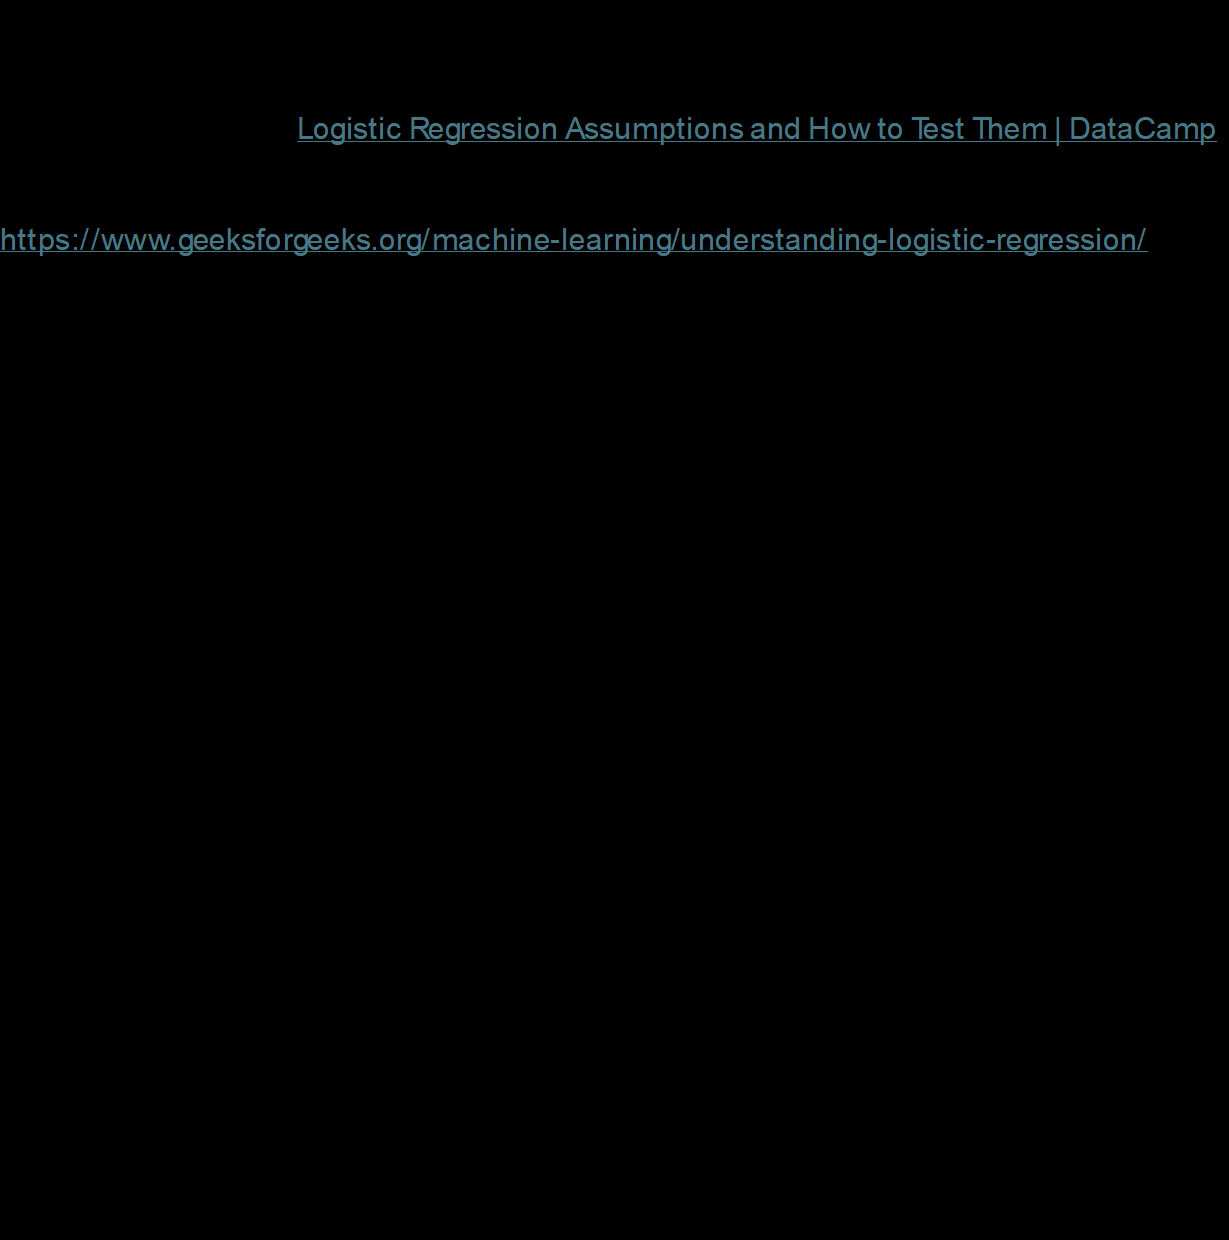
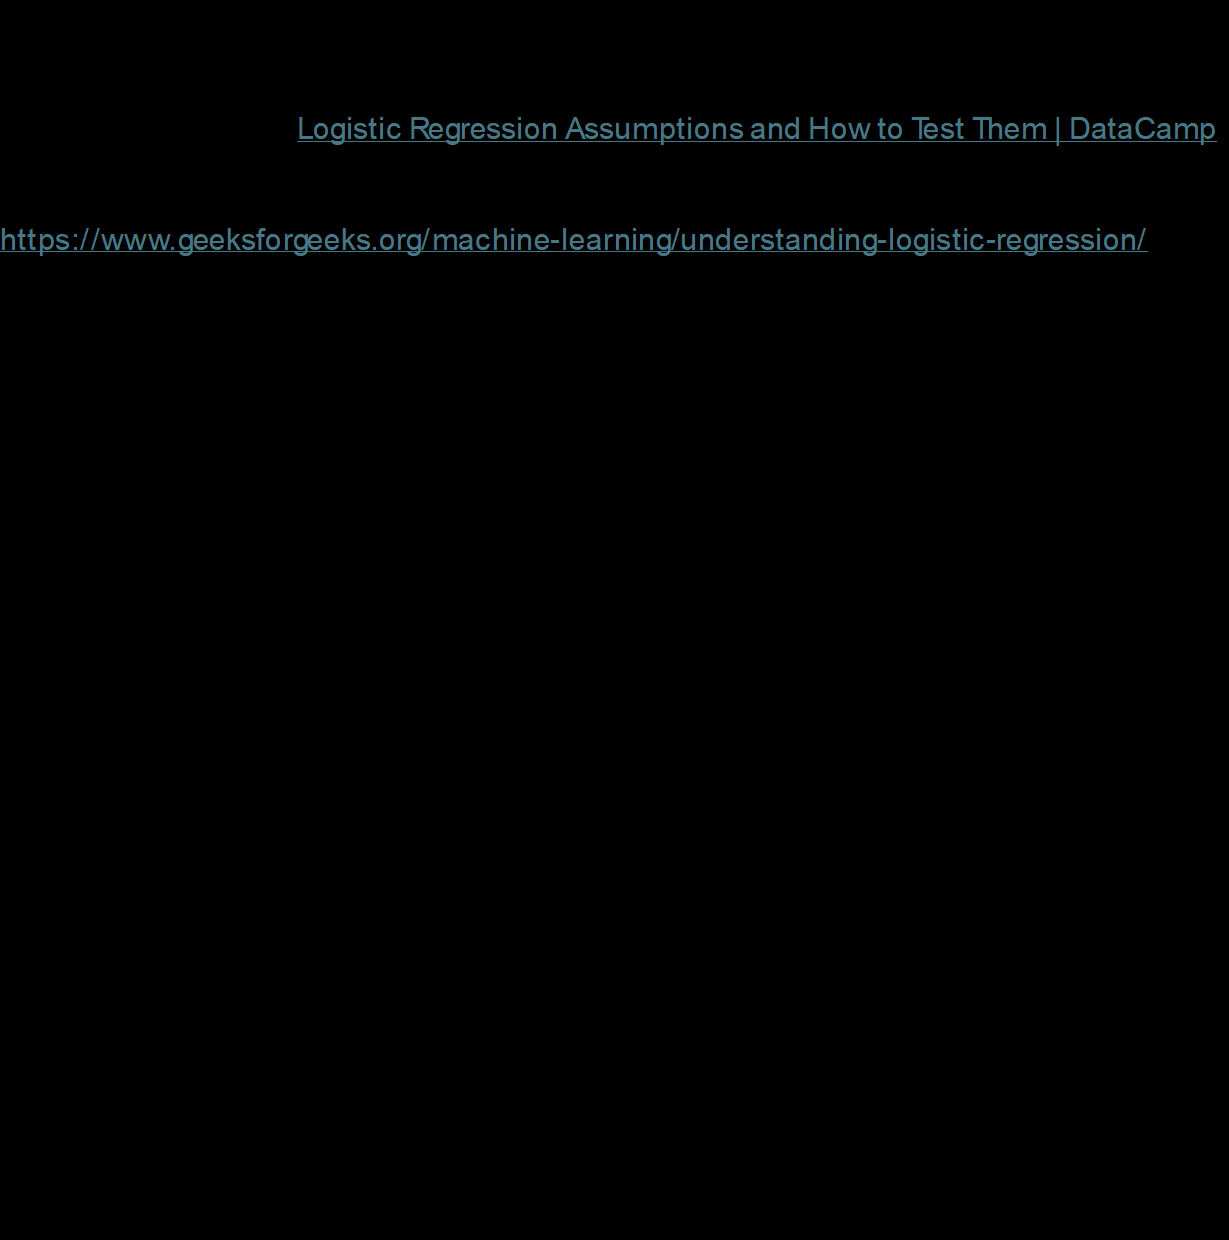
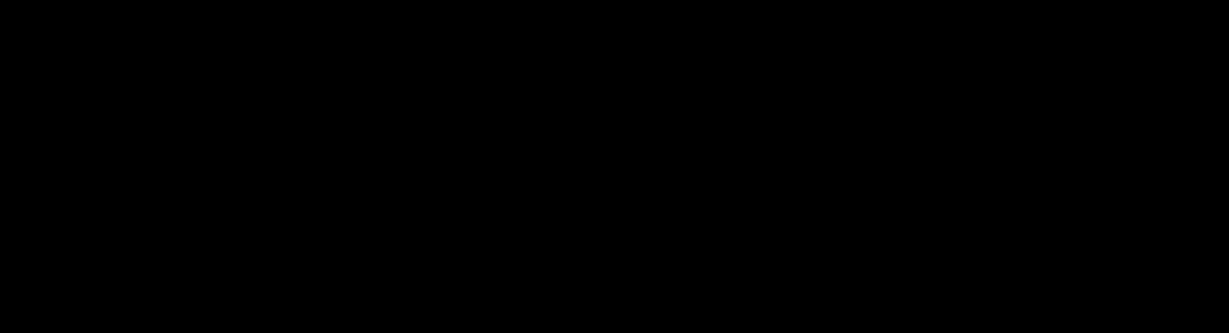

**Answer:**

Model 2: Random Forest Classifier

A Random Forest Classifier Model is well-suited to classify whether a patient has a certain disease based on patient symptoms, lab results, and medical history. Because medical decisions often depend on many different factors that interact in complex ways, Random Forest can learn these relationships and classify patients into categories such as disease present or disease absent. By combining the predictions of many different decision trees, this model often produces more accurate and reliable classifications than a single decision tree, making it a valuable tool in healthcare (IBM, n.d.).

One of the main strengths of a Random Classifier Model is its ability to model complex, nonlinear relationships between data variables without requiring extensive data preprocessing. It performs well on datasets containing many features and is less likely to overfit than a single decision tree because it combines the predictions of many decision trees. Additionally, Random Forest can estimate feature importance, making it easier to understand which variables contribute most to the model. Furthermore, this model is able to handle missing values, making it a valuable tool to employ when it is known that data is missing in a dataset (Kavlakoglu, n.d.).

One of the main disadvantages of the Random Forest Classifier is the amount of computational resources it requires as compared to simpler models since it computes data for many, uncorrelated trees. Additionally, if storage is a problem, then this model may not be appropriate. Storing the larger datasets that are processed by the Random Forest Classifier will require more storage than the data stored using smaller dataset or less complex classification models (Kavlakoglu, n.d.).

The Random Forest Classifier Model is a good candidate for predicting whether an individual makes more than \\$50,000 per year since the census income data contains both categorical and numerical values that were converted using one-hot encoding, creating many features with potentially complex relationships. This classifier can learn nonlinear relationships and interactions among variables without assuming a linear relationship between feartures and the target variable. Since the goal is to classify whether an individual's income exceeds \\$50,000 per year, Random Forest Classifier is a flexible and easily applied approach for solving this binary classification problem.


**Answer:**<br>
Model 3: Gradient Boosting Classifier

One area in industry where the Gradient Boosting Classifier can be utilized is in cybersecurity. By analyzing complicated network traffic and usage patterns, this model can detect potential breaches, enabling prevention of attacks and security breaches, protecting sensitive data from the outside world, protecting businesses from financial liability and fallout.

Gradient Boosting Classifier model performs well in real-world situations, where multicollinearity exists between feature variables of various types in a nonlinear manner. Its predictions often perform better than simpler models both because it can be highly tuned using several hyperparameters and because it arrives at its conclusions by iteratively adjusting the model to strengthen its predictive power (Lee, S, 2025). Furthermore, it excels when working on classification problems using tabluar data (Noble, J., n.d.) or high-dimensional datasets (*Gradient Boosting*, n.d.).

Gradient Boosting does not do well when the classes are imbalanced, and will result in inaccurate predictions that favor the class with the most observations. While this can be counterbalanced through over or undersampling, using weighted loss functions, and carefully tuned hyperparameters, it makes employing this model much more complex (Clark & Lee, n.d.). This model is also not as good to use with very large dataset, or where computational efficiency is very important. Furthermore, data with outliers may negatively affect the results when training this model, as the model may overfit to them (Noble, n.d.).

The Gradient Boosting Classifier is a good model for predicting whether an individual makes more than \$50,000 per year because the census data contains many variables that may interact in complex ways. The combination of continuous and one-hot encoded categorical variables allows the algorithm to learn nonlinear relationships that may not be captured by simpler models. Additionally, the Gradient Boosting Classifier is designed to improve prediction accuracy by iteratively improving its accuracy by building each weak model by correcting errors made on previous weak models (Clark & Lee, n.d.). This makes it well-suited for tabular datasets structured such as the census data.


### Implementation - Creating a Training and Predicting Pipeline

In [14]:
# Import two metrics from sklearn - fbeta_score and accuracy_score
# Import time from time
from sklearn.metrics import fbeta_score, accuracy_score
from time import time

def train_predict(learner, sample_size, X_train, y_train, X_test, y_test): 
    '''
    inputs:
       - learner: the learning algorithm to be trained and predicted on
       - sample_size: the size of samples (number) to be drawn from training set
       - X_train: features training set
       - y_train: income training set
       - X_test: features testing set
       - y_test: income testing set
    '''
    
    results = {}
    
    # Fit the learner to the training data using slicing with 'sample_size' using .fit(training_features[:], training_labels[:])
    start = time() # Get start time
    learner.fit(X_train[:sample_size], y_train[:sample_size])
    end = time() # Get end time
    
    # Calculate the training time
    results['train_time'] = end - start
        
    # Get the predictions on the test set(X_test),
    # then get predictions on the first 300 training samples(X_train) using .predict()
    start = time() # Get start time
    predictions_test = learner.predict(X_test)
    predictions_train = learner.predict(X_train[:300])
    end = time() # Get end time
    
    # Calculate the total prediction time
    results['pred_time'] = end - start
            
    # Compute accuracy on the first 300 training samples which is y_train[:300]
    results['acc_train'] = accuracy_score(y_train[:300], predictions_train)
        
    # Compute accuracy on test set using accuracy_score()
    results['acc_test'] = accuracy_score(y_test, predictions_test)
    
    # Compute F-score on the the first 300 training samples using fbeta_score()
    results['f_train'] = fbeta_score(y_train[:300], predictions_train, beta = 0.5)
        
    # Compute F-score on the test set which is y_test
    results['f_test'] = fbeta_score(y_test, predictions_test, beta = 0.5)
       
    # Success
    print("{} trained on {} samples.".format(learner.__class__.__name__, sample_size))
        
    # Return the results
    return results

### Implementation: Initial Model Evaluation

LogisticRegression trained on 361 samples.
LogisticRegression trained on 3617 samples.
LogisticRegression trained on 36177 samples.
RandomForestClassifier trained on 361 samples.
RandomForestClassifier trained on 3617 samples.
RandomForestClassifier trained on 36177 samples.
GradientBoostingClassifier trained on 361 samples.
GradientBoostingClassifier trained on 3617 samples.
GradientBoostingClassifier trained on 36177 samples.


C:\Users\steff\PycharmProjects\JupyterProject2\visuals.py:122: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  pl.tight_layout()


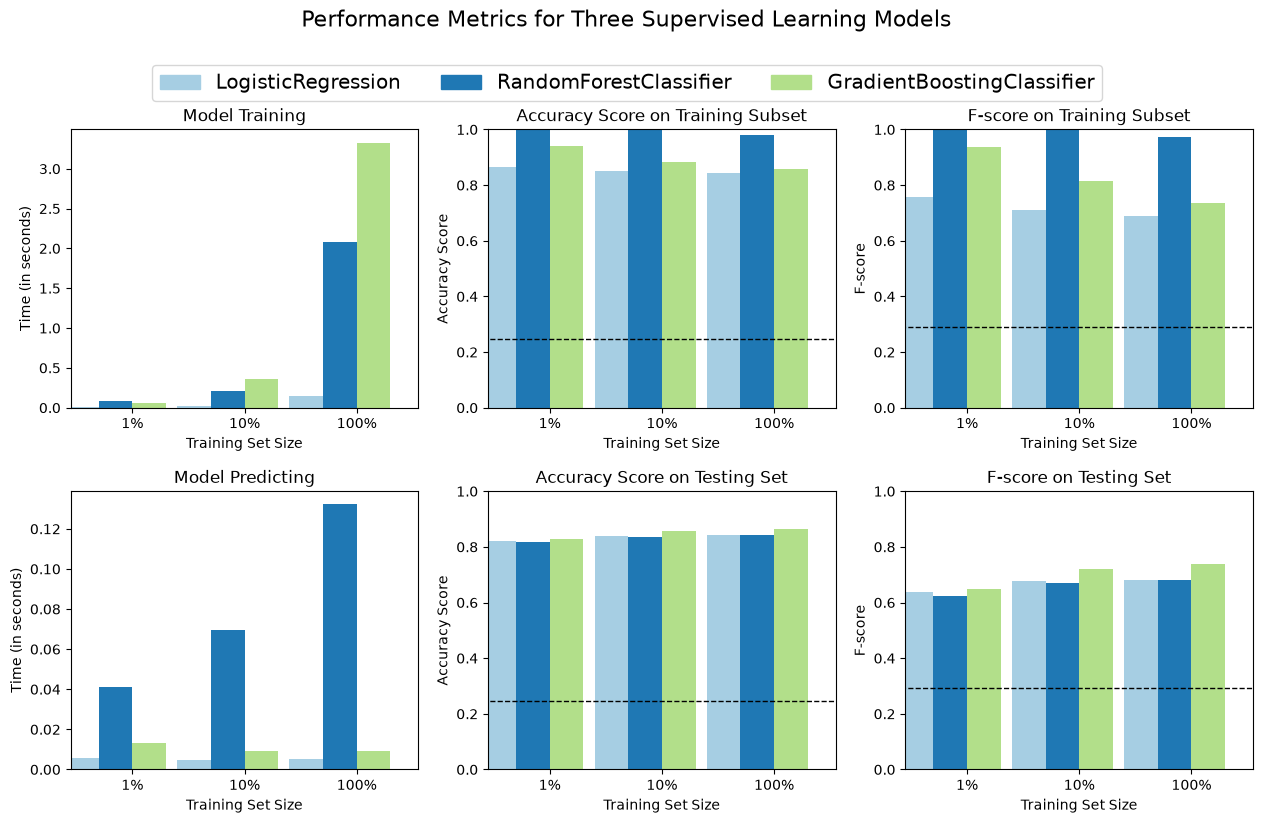

In [29]:
# Import RandomForestClassifier, GradientBoostingClassifier, and LogisticRegression supervised learning models from sklearn
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Initialize the three models
clf_A = LogisticRegression()
clf_B = RandomForestClassifier()
clf_C = GradientBoostingClassifier()

# Calculate the number of samples for 1%, 10%, and 100% of the training data
# HINT: samples_100 is the entire training set i.e. len(y_train)
# HINT: samples_10 is 10% of samples_100 (ensure to set the count of the values to be `int` and not `float`)
# HINT: samples_1 is 1% of samples_100 (ensure to set the count of the values to be `int` and not `float`)
samples_100 = len(y_train)
samples_10 = int(0.10*samples_100)
samples_1 = int(0.01*samples_100)

# Collect results on the learners
results = {}
for clf in [clf_A, clf_B, clf_C]:
    clf_name = clf.__class__.__name__
    results[clf_name] = {}
    for i, samples in enumerate([samples_1, samples_10, samples_100]):
        results[clf_name][i] = \
        train_predict(clf, samples, X_train, y_train, X_test, y_test)

# Run metrics visualization for the three supervised learning models chosen
vs.evaluate(results, accuracy, fscore)

----
## Improving Results

### Question 3 - Choosing the Best Model

* Based on the evaluation you performed earlier, in one to two paragraphs, explain to *CharityML* which of the three models you believe to be most appropriate for the task of identifying individuals that make more than $50,000.

**Answer:**
The Gradient Boosting Classifier model achieved the highest F-score on the testing set (approximately 0.74) when trained on the full training dataset, outperforming both the Logistic Regression and Random Forest Classifier Models. Although the Gradient Boosting Classifier Model took the longest time of the three models to train, its prediction time on the testing data was very low, making it efficient when classifying new observations after training. In addition, Gradient Boosting is well suited for the identifying individuals that make more than \$50,000 using the census income dataset because it can model complex linear relationships and feature interactions among the categorical and continuous variables. These characteristics, combined with its superior predictive performance, makes it the strongest and most appropriate candidate for meeting CharityML's needs.

### Question 4 - Describing the Model in Layman's Terms

* In one to two paragraphs, explain to *CharityML*, in layman's terms, how the final model chosen is supposed to work. Be sure that you are describing the major qualities of the model, such as how the model is trained and how the model makes a prediction.

**Answer:**
The final model chosen is the Gradient Boosting Classifier. Rather than relying on a single decision tree to make predictions, Gradient Boosting builds many small decision trees, one after another, during the training process. Each new tree focuses on correcting the mistakes made by the trees that were built before it. As more trees are added, the model gradually becomes better at recognizing the patterns that separate individuals who earn more than \$50,000 per year from those who earn less. By learning from its previous mistakes, the model is able to identify complex relationships between characteristics such as age, marital status, education, occupation, and hours worked per week without requiring those relationships to be obvious or easily detected (Clark & Lee, n.d.).

Once the model has been trained, it can evaluate information about a new individual that it has never seen before. *CharityML* can then use these predictions to identify individuals who are more likely to have higher incomes and focus fundraising efforts on those people. The organization is able to spend less time and money contacting individuals who are less likely to make large donations while directing resources to those individuals who are more likely to contribute.

### Implementation: Model Tuning
Fine tune the Gradient Boosting Classifier model.

In [16]:
# Import 'GridSearchCV' and 'make_scorer'
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
# Initialize the classifier
clf = GradientBoostingClassifier(random_state= 42)

# Create the parameters list for tuning
parameters = {'n_estimators': [125, 150, 175, 200, 225], 'learning_rate': [0.025, 0.05, 0.075], 'max_depth': [3, 4, 5, 6], 'subsample': [0.5, 0.6, 0.7] }

# Make an fbeta_score scoring object using make_scorer()
scorer = make_scorer(fbeta_score, beta=0.5)

# Perform grid search on the classifier using 'scorer' as the scoring method using GridSearchCV()
grid_obj = GridSearchCV(clf, parameters, scoring=scorer, cv = 3, n_jobs = -1, verbose = 2)

# Fit the grid search object to the training data and find the optimal parameters using fit()
grid_fit = grid_obj.fit(X_train, y_train)

# Get the estimator
best_clf = grid_fit.best_estimator_

# Make predictions using the unoptimized and model
predictions = (clf.fit(X_train, y_train)).predict(X_test)
best_predictions = best_clf.predict(X_test)

# Report the before-and-afterscores
print("Unoptimized model\n------")
print("Accuracy score on testing data: {:.4f}".format(accuracy_score(y_test, predictions)))
print("F-score on testing data: {:.4f}".format(fbeta_score(y_test, predictions, beta = 0.5)))
print("\nOptimized Model\n------")
print("Final accuracy score on the testing data: {:.4f}".format(accuracy_score(y_test, best_predictions)))
print("Final F-score on the testing data: {:.4f}".format(fbeta_score(y_test, best_predictions, beta = 0.5)))

Fitting 3 folds for each of 180 candidates, totalling 540 fits
Unoptimized model
------
Accuracy score on testing data: 0.8630
F-score on testing data: 0.7395

Optimized Model
------
Final accuracy score on the testing data: 0.8687
Final F-score on the testing data: 0.7479


In [18]:
# Dictionary result containing the set of parameters for the optimized model
grid_fit.best_params_

{'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 125, 'subsample': 0.7}

### Question 5 - Final Model Evaluation

* What is your optimized model's accuracy and F-score on the testing data? 
* Are these scores better or worse than the unoptimized model? 
* How do the results from your optimized model compare to the naive predictor benchmarks you found earlier in **Question 1**?

#### Results:

|     Metric     | Naive Bayes | Unoptimized Model | Optimized Model |
|:--------------:|:-----------:|------------------:|:---------------:|
| Accuracy Score |   0.2478    |            0.8630 |     0.8687      |
|    F-score     |   0.2917    |            0.7395 |     0.7479      |


**Answer:**
The optimized Gradient Boosting Classifier model achieved an accuracy score of 0.8687 and an F-score (beta = 0.5) of 0.7479 on the testing data. Compared to the unoptimized model, which achieved an accuracy score of 0.8630 and an F-score of 0.7395, hyperparameter tuning resulted in modest improvements to both metrics. Although the increases were fairly small, they indicate that the optimized model generalized slightly better to unseen data while maintaining strong overall performance. Despite the modest improvement of the optimized model, its predictive performance could translate into meaningful donations when utilized during a large fundraising campaign by allowing *CharityML* to identify additional potential donors while reducing resources spent contacting individuals less likely to contribute.

The optimized model performs substantially better than the naive predictor. The naive predictor achieved an accuracy score of 0.2478 and an F-score of 0.2917 because it predicted that every individual scored more than \\$50,000 per year. In contrast, the optimized Gradient Boosting Classifier model learned meaningful relationships and patterns from the training data and was able to distinguish between those who were likely and those who were unlikely to earn more than \\$50,000 per year. The Gradient Boosting Classifier model, therefore, demonstrated a substantially higher accuracy and F-score, strongly supporting it as a far more effective choice for aiding *CharityML* in its search for potential donors.

----
## Feature Importance

### Question 6 - Feature Relevance Observation
When **Exploring the Data**, it was shown there are thirteen available features for each individual on record in the census data. Of these thirteen records, which five features do you believe to be most important for prediction, and in what order would you rank them and why?

**Answer:**
I believe occupation, workclass, education, age, and sex will be the top 5 features most important for predicting income class. Certain occupations and workclasses are generally associated with higher-paying jobs, making them likely to be predictive of income. Likewise, individuals with higher levels of education are often qualified for positions that offer greater earning potential. In addition, older individuals have generally had more time to gain work experience, receive promotions, increase their salary. Finally, I expect sex to be an important predictor because differences in occupational representation and earnings between men and women may influence income patterns within the dataset.

### Implementation - Extracting Feature Importance
Extract the feature importances using `.feature_importances_`.

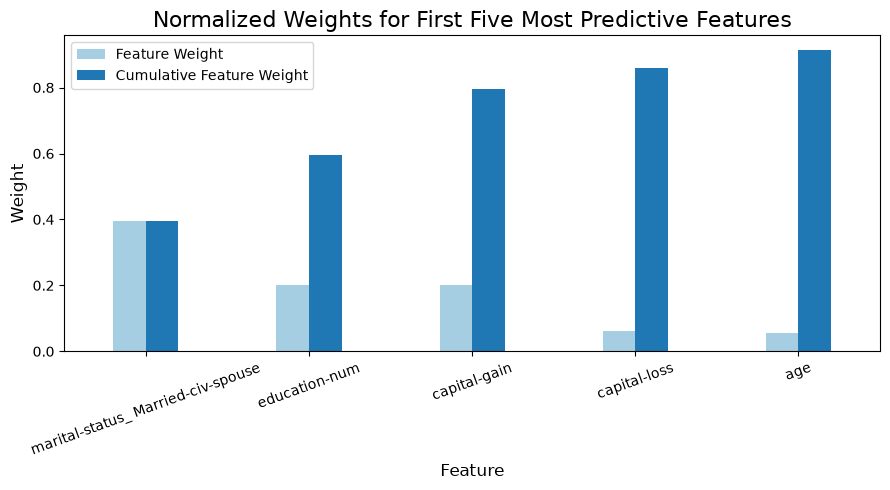

In [21]:
# The GradientBoostingClassifier model was previously imported

# Instantiate the model
model = GradientBoostingClassifier(random_state= 42)
# Train the supervised model on the training set using .fit(X_train, y_train)
model.fit(X_train, y_train)

# Extract the feature importances using .feature_importances_
importances = model.feature_importances_

# Plot
vs.feature_plot(importances, X_train, y_train)

### Question 7 - Extracting Feature Importance

Observe the visualization created above which displays the five most relevant features for predicting if an individual makes at most or above $50,000.  
* How do these five features compare to the five features you discussed in **Question 6**?
* If you were close to the same answer, how does this visualization confirm your thoughts? 
* If you were not close, why do you think these features are more relevant?

**Answer:**

I initially expected occupation, workclass, education, age, and sex to be the most important predictive features because they all seem directly related to an individual's earning power. However, the feature_importances_ attribute identified marital_status_Married_civ_spouse, education_num, capital_gain, capital_loss, and age as the most important predictive features. Age was the only feature that matched my prediction, probably because it reflects work experience and career progression. Upon reflection, I now realize that the remaining four features provide more direct information concerning an individual's education level, investment activity, and financial situation than the features I selected. For example, education-num represents years of education in a format that is easier for the model to use than separate education categories, and capital-gain and capital-losses reflect investment activity that is more common among higher-income individuals. Although some of the selected features appear to be related to one another, such as age and marital status or capital gains and losses, each contributes unique information that helps the model distinguish between individuals who earn more than \\$50,000 per year and those who do not.

### Feature Selection
Create a clone of the optimized model and train it on the 5 most important predictive features

In [22]:
# Import functionality for cloning a model
from sklearn.base import clone

# Reduce the feature space
X_train_reduced = X_train[X_train.columns.values[(np.argsort(importances)[::-1])[:5]]]
X_test_reduced = X_test[X_test.columns.values[(np.argsort(importances)[::-1])[:5]]]

# Train on the "best" model found from grid search earlier
clf = (clone(best_clf)).fit(X_train_reduced, y_train)

# Make new predictions
reduced_predictions = clf.predict(X_test_reduced)

# Report scores from the final model using both versions of data
print("Final Model trained on full data\n------")
print("Accuracy on testing data: {:.4f}".format(accuracy_score(y_test, best_predictions)))
print("F-score on testing data: {:.4f}".format(fbeta_score(y_test, best_predictions, beta = 0.5)))
print("\nFinal Model trained on reduced data\n------")
print("Accuracy on testing data: {:.4f}".format(accuracy_score(y_test, reduced_predictions)))
print("F-score on testing data: {:.4f}".format(fbeta_score(y_test, reduced_predictions, beta = 0.5)))

Final Model trained on full data
------
Accuracy on testing data: 0.8687
F-score on testing data: 0.7479

Final Model trained on reduced data
------
Accuracy on testing data: 0.8593
F-score on testing data: 0.7271


### Question 8 - Effects of Feature Selection

* How does the final model's F-score and accuracy score on the reduced data using only five features compare to those same scores when all features are used?
* If training time was a factor, would you consider using the reduced data as your training set?

**Answer:**

When the optimized Gradient Boosting Classifier model was trained using only the five most important predictive features, the accuracy score decreased from 0.8687 to 0.8593, while the F-score decreased from 0.7479 to 0.7271. Although both metrics declined slightly, the reduction in predictive performance was relatively small considering that the model was trained using only five of the original 103 factors. This suggests that much of the predictive information contained in the full dataset is held within a relatively small number of features.

If training time were an important consideration, I would consider using the decreased dataset. As shown earlier in the analysis, training the Gradient Boosting classifier model required more time than the other two models because it builds many decision trees sequentially. Using only 5 of the 103 original features reduces the complexity of the training data and would generally decrease training time while maintaining performance close to the optimized model trained on the full set of features. In instances where computational resources or training time are limited, this tradeoff could be worthwhile. However, if predictive performance was the primary objective, I would still choose to use the full set of features because that results in the highest accuracy and F-score.

**References:**<br><br>
Clark, B., & Lee, F. (n.d.). *What is gradient boosting?* IBM. https://www.ibm.com/think/topics/gradient-boosting? <br>

*Gradient Boosting.* (n.d.). Polymer. https://www.polymer.search.com/glossary/gradient-boosting <br>

Kavlakoglu, E. (n.d.). *What is random forest?* IBM. https://www.ibm.com/think/topics/random-forest? <br>

*Logistic Regression in Machine Learning.* (2026). Geeks for Geeks. https://www.geeksforgeeks.org/machine-learning/understanding-logistic-regression/
<br>

Noble, J. (2025). *Gradient Boosting classifiers in Scikit-Learn and Caret.* IBM. https://www.ibm.com/think/tutorials/gradient-boosting-classifier#179371088 <br>

Radečić, D. (2026). *Logistic Regression Assumptions: What You Need to Check Before Modeling.* Datacamp. https://www.datacamp.com/tutorial/logistic-regression-assumptions?
<br>